# Counterfactual Analysis

In [2]:
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from catboost import CatBoostClassifier

from pathlib import Path
import shutil
import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

import dice_ml

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Counterfactuals Module

In [2]:
from utils2 import counterfactuals as cf

## Read Config File

In [3]:
config_path = Path(r'experiments')
config_filename =  "bin_cf_dev.yml"
config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict

{'experiment': {'summary': 'binary classification - Counterfactual Analysis (Dev)',
  'classification_type': 'binary',
  'stage': 'counterfactuals',
  'tag': 'development',
  'verbosity': 1,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'model': {'code': 'catboost', 'name': 'CatBoost'},
 'explainability': {'ksplit_trained_model_results_file': 'binary\\explainability\\catboost\\final\\catboost_ksplit_trained_models.joblib',
  'rundate': '2026-03-18',
  'tag': 'final'},
 'dice': {'method': 'genetic',
  'global_cf': {'total_CFs': 10, 'posthoc_sparsity_param': 'None'},
  'local_cf': {'nrepeats': 2,
   'total_CFs': 20,
   'posthoc_sparsity_algorithm': 'binary',
   'posthoc_sparsity_param': 0.05,
   'proximity_weight': 0.5,
   'diversity_weight': 1.0,
   'categorical_penalty': 0.1,
   'algorithm': 'DiverseCF'},
  'sufficiency': {'maxiterations': 200},
  'necessity': {'maxiterations': 500, 'total_CFs': 2, 'nrepeats': 5}},
 'reporting': {

#### Set output directory

In [4]:
outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.model.code / config.experiment.tag 
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\counterfactuals\catboost\development


#### Copy config file to output directory

In [5]:
source = config_path / config_filename
destination = outputdir / config_filename
shutil.copy(source, destination)

WindowsPath('experiments/binary/counterfactuals/catboost/development/bin_cf_dev.yml')

## Data Loading

In [6]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type)

dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

In [7]:
dfXy = pd.concat([X, y], axis=1)
X.shape, y.shape, dfXy.shape

((190, 40), (190,), (190, 41))

### Define custom column lists

In [8]:
features_to_vary = dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list()
continuous_cols = dfXy.columns.difference(D.categorical_cols+['SEX', 'Confirmed_Binary_DPN']).to_list()
print('features to vary columns:\n', len(features_to_vary), features_to_vary)
print('categorical columns:\n', len(D.categorical_cols), D.categorical_cols)
print('continuous_columns:\n', len(continuous_cols), continuous_cols)

features to vary columns:
 39 ['AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R', 'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'NS', 'CAS']
categorical columns:
 12 ['SEX', 'SUBJ', 'INSULIN', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR']
continuous_columns:
 28 ['AGE', 'CAS', 'CMAPANK_L', 'CMAPANK_R', 'CMAPKNE_L', 'CMAPKNE_R', 'DL_L', 'DL_R', 'DM_DUR', 'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'FWAVE_L', 'FWAVE_R', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'HBA1C', 'MCV_L', 'MCV_R', 'MNSI', 'NS', 'SPSA_L', 'SPSA_R', 'SPSC_L', 'SPSC_R', 'SSA_L', 'SSA_R', 'SSC_L', 'SSC_R']


## Load trained model splits from Explainability Stage

### Load Models and Check Rundate and Tag

In [11]:
ksplit_trained_models = joblib.load(config_path / config.explainability.ksplit_trained_model_results_file)
assert ksplit_trained_models['rundate'] == config.explainability.rundate, f"{ksplit_trained_models['rundate']} != {config.explainability.rundate}"
assert ksplit_trained_models['tag'] == config.explainability.tag
print('rundate:', ksplit_trained_models['rundate'])
print('tag:', ksplit_trained_models['tag'])
ksplit_trained_models['summary']

rundate: 2026-03-18
tag: final


,0,1,2,mean,std
youden,0.909,0.727,0.784,0.807,0.076
roc_auc,0.983,0.986,0.944,0.971,0.019


In [12]:
split_results = ksplit_trained_models['results']
split_results[0]

{'model': <catboost.core.CatBoostClassifier at 0x25829269010>,
 'X_train':      SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0      1  64.0     1     7.0      1.0  15.00    0     0         0    0    0   
 1      0  59.0     1     1.0      0.0   5.60    1     0         0    0    0   
 5      0  20.0     1     2.0      1.0   7.80    0     0         0    0    0   
 6      0  69.0     0     0.0      0.0   8.00    1     0         1    0    0   
 7      0  60.0     0     2.0      0.0   5.80    1     0         0    0    0   
 8      1  62.0     0     0.0      1.0  14.36    0     0         0    0    0   
 9      0  44.0     1    17.0      0.0   7.01    0     0         0    0    0   
 10     0  70.0     0    10.0      0.0   6.40    1     0         0    1    0   
 11     1  61.0     1     4.0      0.0   8.30    0     0         1    1    0   
 12     1  57.0     1     7.0      1.0  13.00    0     0         1    0    0   
 14     0  78.0     1     5.0      0.0   5.00 

### Extract Train and Test Sets

In [14]:
# Choose a model split
midx = 0

# Create output directory for this Model split
split_output_dir = outputdir / f'split{midx}'
split_output_dir.mkdir(parents=True, exist_ok=True)

# Extract saved variables from split
threshold = split_results[midx]['threshold']
best_params = split_results[midx]['best_params']

# Extract test set
X_test = split_results[midx]['X_test']
y_test = split_results[midx]['y_test']
dfXy_test = pd.concat([X_test, y_test], axis=1)
X_test.shape, y_test.shape, dfXy_test.shape, threshold

((64, 40), (64,), (64, 41), 0.6352084424142594)

In [17]:
X_train = split_results[midx]['X_train']
X_test = split_results[midx]['X_test']

# convert categorical columns in X_train - needed in CatBoost for use in DiCE
X_train[D.categorical_cols] = X_train[D.categorical_cols].astype(str)
X_test[D.categorical_cols] = X_test[D.categorical_cols].astype(str)

y_train = split_results[midx]['y_train']
y_test = split_results[midx]['y_test']

## Prepare Explainer

### Refit the model 

In [46]:
### Refit model so we can set cat_features (needed in DiCE)
model=  CatBoostClassifier(**best_params, 
                           cat_features=D.categorical_cols, 
                           verbose=0
                           ).fit(X_train, y_train)

###  Wrap model for threshold

In [47]:
# Wrap model so we can use a custom threshold
wrapped_model = cf.CatBoostWrapper(model, threshold)
cf.test_wrapped_model(model, wrapped_model, X_test, y_test, threshold)

Confusion Matrix at default threshold (0.5):
[[20  0]
 [ 3 41]]
Confusion Matrix at custom threshold (0.6352084424142594):
[[20  0]
 [ 4 40]]
Rows with different predictions at thresholds: 


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,pred_0.50,pred_0.64,pred_proba
106,1,33.0,1,3.0,1.0,9.0,0,0,0,0,0,0,1,0,1,3.0,4.88,49.2,0.0,0.0,43.2,3.5,13.14,10.75,43.3,2.68,45.3,0.0,0.0,44.0,3.45,9.98,7.18,42.4,76.0,0.0,76.0,12.0,90.0,4.0,1,0,0.524


## DiCE Explainer Object Setup

###  Define Global Permitted Range

In [20]:
global_permitted_range = cf.get_global_permitted_range(
    dfXy, continuous_cols, config, midx, verbosity=1, savedir=split_output_dir)

,min,max
AGE,8.111,100.889
CAS,0.000,58.027
CMAPANK_L,0.000,29.589
CMAPANK_R,0.000,31.434
CMAPKNE_L,0.000,22.551
CMAPKNE_R,0.000,23.008
DL_L,0.000,48.650
DL_R,0.000,16.399
DM_DUR,0.000,37.797
FEET_MEAN_ESC,0.000,106.560


### Define DiCE Explainer Object

In [22]:
d = dice_ml.Data(dataframe=dfXy_test, # use only the test set
                 continuous_features=continuous_cols,                  
                 categorical_features=D.categorical_cols,
                 permitted_range = global_permitted_range, 
                 outcome_name='Confirmed_Binary_DPN')

m = dice_ml.Model(model=wrapped_model, backend="sklearn", model_type="classifier")
dexp = dice_ml.Dice(d, m, method=config.dice.method)

## Get Global Importances

In [23]:
cf.get_global_importance(dexp, D, X_test, config, midx, 
                         features_to_vary, threshold, global_permitted_range,
                         highlight_features=cf.actionable_cols, 
                         filename_suffix="", savedir=split_output_dir)

experiments\binary\counterfactuals\catboost\development\split0\catboost_split0_global_importance.png already exists.


## Local Counterfactual Analysis

##### Local Permitted Range for a Patient 

In [38]:
pidx = 67
split_instance_output_dir = split_output_dir / f'{str(pidx).zfill(3)}_temp'
split_instance_output_dir.mkdir(parents=True, exist_ok=True)

query_instance = X[pidx:pidx+1]
instance_permitted_range = cf.get_local_permitted_range(
    dfXy, query_instance, features_to_vary, D.categorical_cols, continuous_cols, cf.progressive_cols,
    config, midx, savedir=split_instance_output_dir)

Local permitted range:


,instance,min,max
SEX,1.00,NaN,NaN
AGE,56.00,56.000,67.889
SUBJ,1.00,NaN,NaN
DM_DUR,0.00,0.000,7.797
INSULIN,0.00,NaN,NaN
HBA1C,5.10,2.385,7.815
HPN,0.00,NaN,NaN
PAOD,0.00,NaN,NaN
DSLPDMIA,0.00,NaN,NaN
CKD,0.00,NaN,NaN


##### Generate 5 Sample Local Counterfactuals for a Patient

In [39]:
e1 = cf.generate_sample_local_cf_with_permitted_range(dfXy, dexp, query_instance, instance_permitted_range, config, CFs=3)
e1_cfdf = e1.cf_examples_list[0].final_cfs_df

generating counterfactuals for the CatBoost model


100%|██████████| 1/1 [00:00<00:00,  2.10it/s]

Query instance (original outcome : 0)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1,56.0,1,0.0,0.0,5.1,0,0,0,0,0,0,0,0,0,3.0,16.27,52.0,12.16,50.7,46.6,3.75,9.46,6.93,47.0,13.8,50.0,13.48,53.0,43.8,3.2,7.41,5.61,47.7,71.0,8.0,63.0,6.0,60.0,30.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,64.0,-,-,1.0,-,1.0,-,1.0,-,-,-,-,-,1.0,-,16.3,34.2,12.2,30.5,-,4.55,7.29,5.49,-,-,31.3,13.5,-,-,4.4,7.67,5.19,58.4,-,-,-,0.0,-,-,1.0
0,-,-,-,-,-,2.4,1.0,-,-,1.0,-,-,-,1.0,-,-,16.3,-,12.2,43.5,39.9,3.45,4.67,3.55,48.3,-,37.1,13.5,-,36.6,4.3,8.07,-,-,-,3.0,-,-,-,26.0,1.0
0,-,-,-,-,-,-,1.0,-,-,-,-,-,1.0,1.0,-,-,16.3,42.8,12.2,-,-,4.8,6.78,5.11,48.8,5.0,42.7,13.5,-,42.0,3.75,7.47,5.04,-,-,15.0,-,-,61.0,28.0,1.0


In [40]:
e1_cfdf.head(2)

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1,64.0,1,0.0,1.0,5.1,1,0,1,0,0,0,0,0,1,3.0,16.3,34.2,12.2,30.5,46.6,4.55,7.29,5.49,47.0,13.8,31.3,13.5,53.0,43.8,4.4,7.67,5.19,58.4,71.0,8.0,63.0,0.0,60.0,30.0,1
0,1,56.0,1,0.0,0.0,2.4,1,0,0,1,0,0,0,1,0,3.0,16.3,52.0,12.2,43.5,39.9,3.45,4.67,3.55,48.3,13.8,37.1,13.5,53.0,36.6,4.3,8.07,5.61,47.9,71.0,3.0,63.0,6.0,60.0,26.0,1


### Borderline & Misclassified Local Counterfactuals

In [41]:
ioi_df, display_cols = cf.get_instances_of_interest(
    wrapped_model, X_test, y_test, config=config, split_index=midx, 
    threshold=threshold, delta=0.2, savedir=split_instance_output_dir)

Found 6 misclassified and borderline cases (|p - 0.6352| ≤ 0.2)


,SEX,AGE,SUBJ,DM_DUR,margin,misclassified,pred_proba,pred,actual
4,1,57.0,0,5.0,0.083,False,0.719,1,1
55,0,67.0,1,11.0,0.131,False,0.767,1,1
67,1,56.0,1,0.0,0.449,True,0.187,0,1
106,1,33.0,1,3.0,0.111,True,0.524,0,1
128,0,74.0,1,30.0,0.360,True,0.275,0,1
158,0,43.0,1,2.0,0.598,True,0.037,0,1


In [43]:
ioi_df.loc[pidx][['actual','pred']]

actual    1
pred      0
Name: 67, dtype: object

### Generate Local Counterfactuals

In [44]:
# pidx is set above since instance_permitted_range is dependent on it
query_instance = X[pidx:pidx+1]
df_dcf = cf.generate_diverse_cfs(
    dexp,
    query_instance, 
    config,
    midx,
    threshold=threshold,
    features_to_vary=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list(),
    permitted_range=instance_permitted_range,
    savedir=split_instance_output_dir
    )

df_dcf.shape

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:06<00:00,  6.95s/it]


(22, 41)

### Plot Counterfactuals Heatmaps

diffs.shape:  (22, 41)
batch_ranges:  [(0, 15), (15, 30)]
idx_start, idx_end:  0 15
diff.shape:  (15, 40)
Counterfactual heatmaps saved to catboost_split0_local_cf_qidx067_000-014.png in experiments\binary\counterfactuals\catboost\development\split0\067_temp


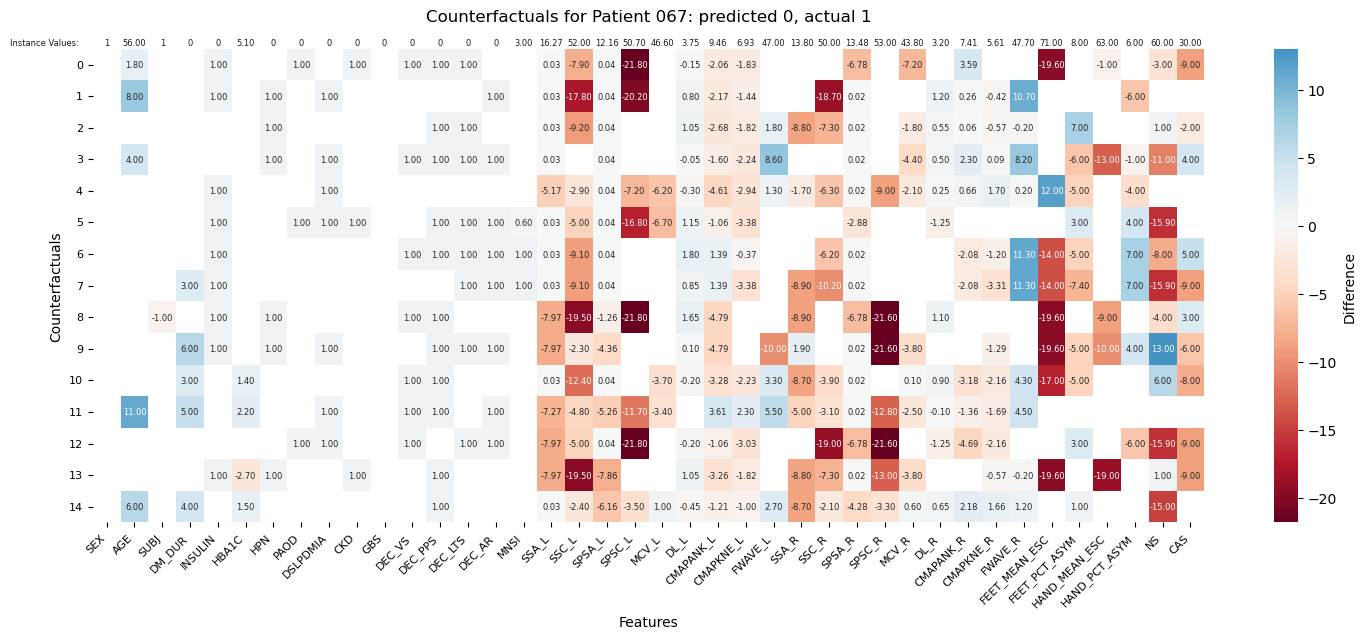

idx_start, idx_end:  15 30
diff.shape:  (7, 40)
Counterfactual heatmaps saved to catboost_split0_local_cf_qidx067_015-021.png in experiments\binary\counterfactuals\catboost\development\split0\067_temp


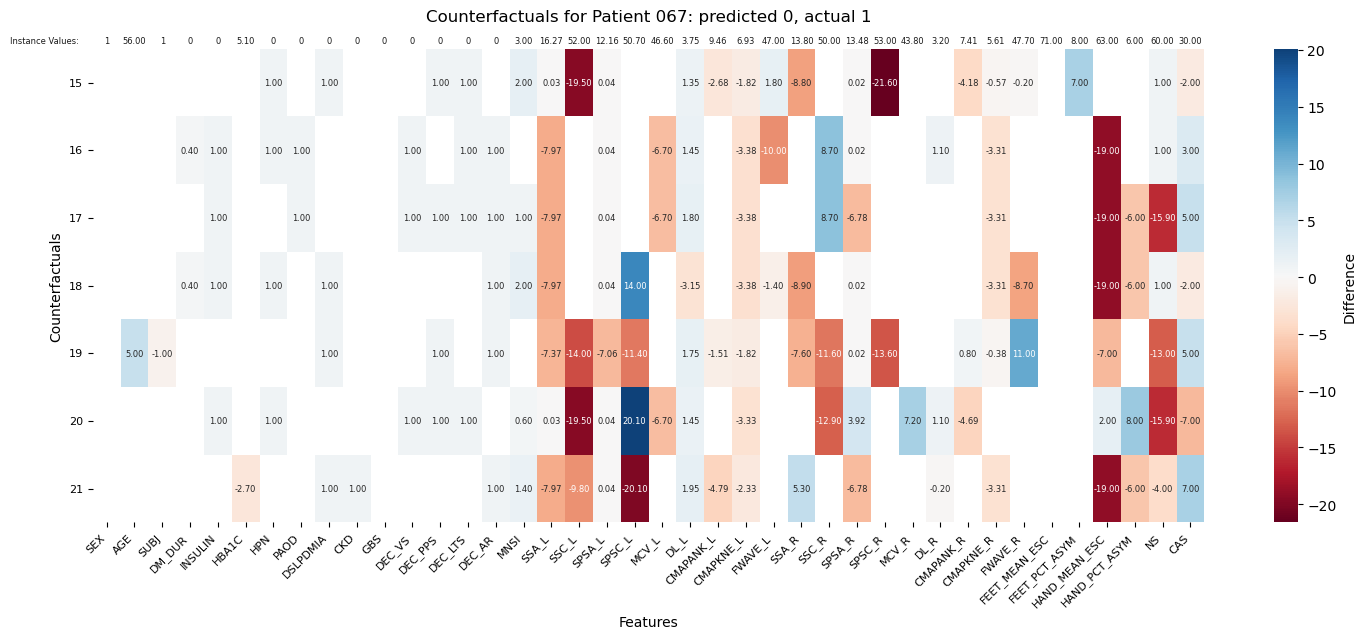

In [48]:
from utils2 import counterfactuals as cf
cf.plot_local_cf_heatmap(dfXy, df_dcf, query_instance, 
                      query_idx=pidx, 
                      pred=ioi_df.loc[pidx]['pred'], 
                      actual=ioi_df.loc[pidx]['actual'], 
                      highlight_invalid=False, categorical_cols=D.categorical_cols, 
                      config=config, split_index=midx,  
                      savedir=split_instance_output_dir)

### Get Most Changed Features

In [49]:
cf.get_most_changed_feature(
    df_dcf, query_instance, config, midx, savedir=split_instance_output_dir)

SSA_L                   22
Confirmed_Binary_DPN    22
SPSA_R                  22
SPSA_L                  22
DL_L                    21
CMAPKNE_L               20
NS                      19
SSC_L                   18
CMAPANK_L               18
CMAPKNE_R               18
CAS                     17
DEC_PPS                 15
CMAPANK_R               14
SSC_R                   14
FWAVE_R                 13
INSULIN                 13
SSA_R                   13
DEC_AR                  13
DL_R                    13
SPSC_L                  12
HAND_PCT_ASYM           12
DEC_LTS                 12
FEET_PCT_ASYM           11
DSLPDMIA                11
HAND_MEAN_ESC           11
FWAVE_L                 10
DEC_VS                  10
MCV_R                   10
HPN                     10
SPSC_R                   9
MNSI                     8
MCV_L                    8
FEET_MEAN_ESC            8
DM_DUR                   7
AGE                      6
PAOD                     5
HBA1C                    5
C

###  Sparsity and L1, L2 Distances

In [50]:
diffs, cf_ana = cf.get_local_cf_distances(
    query_instance, df_dcf, config, midx, sort_by="L2_dist", 
    savedir=split_instance_output_dir)
diffs.head()

,AGE,CAS,CKD,CMAPANK_L,CMAPANK_R,CMAPKNE_L,CMAPKNE_R,Confirmed_Binary_DPN,DEC_AR,DEC_LTS,DEC_PPS,DEC_VS,DL_L,DL_R,DM_DUR,DSLPDMIA,FEET_MEAN_ESC,FEET_PCT_ASYM,FWAVE_L,FWAVE_R,GBS,HAND_MEAN_ESC,HAND_PCT_ASYM,HBA1C,HPN,INSULIN,MCV_L,MCV_R,MNSI,NS,PAOD,SEX,SPSA_L,SPSA_R,SPSC_L,SPSC_R,SSA_L,SSA_R,SSC_L,SSC_R,SUBJ,sparsity,L1_dist,L2_dist
0,1.8,-9.0,1.0,-2.06,3.59,-1.83,0.00,NaN,0.0,1.0,1.0,1.0,-0.15,0.00,0.0,0.0,-19.6,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,1.0,0.0,-7.2,0.0,-3.0,1.0,0.0,0.04,-6.78,-21.8,0.0,0.03,0.0,-7.9,0.0,0.0,22,91.78,33.769
1,8.0,0.0,0.0,-2.17,0.26,-1.44,-0.42,NaN,1.0,0.0,0.0,0.0,0.80,1.20,0.0,1.0,0.0,0.0,0.0,10.7,0.0,0.0,-6.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.04,0.02,-20.2,0.0,0.03,0.0,-17.8,-18.7,0.0,20,91.78,36.086
2,0.0,-2.0,0.0,-2.68,0.06,-1.82,-0.57,NaN,0.0,1.0,1.0,0.0,1.05,0.55,0.0,0.0,0.0,7.0,1.8,-0.2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.8,0.0,1.0,0.0,0.0,0.04,0.02,0.0,0.0,0.03,-8.8,-9.2,-7.3,0.0,22,48.92,17.062
3,4.0,4.0,0.0,-1.60,2.30,-2.24,0.09,NaN,1.0,1.0,1.0,1.0,-0.05,0.50,0.0,1.0,0.0,-6.0,8.6,8.2,0.0,-13.0,-1.0,0.0,1.0,0.0,0.0,-4.4,0.0,-11.0,0.0,0.0,0.04,0.02,0.0,0.0,0.03,0.0,0.0,0.0,0.0,25,73.07,23.210
4,0.0,0.0,0.0,-4.61,0.66,-2.94,1.70,NaN,0.0,0.0,0.0,0.0,-0.30,0.25,0.0,1.0,12.0,-5.0,1.3,0.2,0.0,0.0,-4.0,0.0,0.0,1.0,-6.2,-2.1,0.0,0.0,0.0,0.0,0.04,0.02,-7.2,-9.0,-5.17,-1.7,-2.9,-6.3,0.0,24,75.59,21.806


---

## To DOs

### Prototypical and Atypical
- Prototypical (most representative)
- Atypical (deviating from standard/common)

### Sufficiency

A sufficient feature  change is one that can cause the outcome change by itself.


In [ ]:
all_features = dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list(),

most_changed_features_list = most_changed_features.index.to_list()
confirmed_sufficient_features = ['SSA_R', 'SSA_L', 'DL_L']
forced_timeout_features = ['HBA1C',  'DEC_AR', 'DEC_VS', 'DEC_LTS', 'DEC_PPS', 'CMAPKNE_L', 'FEET_PCT_ASYM', 'INSULIN', 'HPN', 'HAND_PCT_ASYM',  'DSLPDMIA', 'DL_R']
# Other exception: 'SPSA_R'
# No CF exception: 'SPSA_L', 'CMAPANK_L', 'MCV_L', 

# set check_features as needed
check_features = confirmed_sufficient_features[:2]
print(check_features)

df_s = cf.check_sufficiency(
    dexp,
    query_instance,
    check_features=check_features,
    maxiterations=5,
    permitted_range=instance_permitted_range,
    )
df_s

### Necessity

A necessary feature change is one that must be altered; without it, no counterfactual achieves the desired outcome.

In [ ]:
from utils2 import counterfactuals as cf
check_features = ['CAS', 'NS']
df_ns = cf.check_necessity(
    dexp,
    query_instance,
    all_features=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list(),
    maxiterations=500,
    total_CFs=2,
    permitted_range=instance_permitted_range,
    nrepeats=5,
    verbose=False
    )
df_ns

## Study on Counterfactual Visualization

Index(['INSULIN', 'HBA1C', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'DEC_VS',
       'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI'],
      dtype='object')
********** 24 15.0 12.0


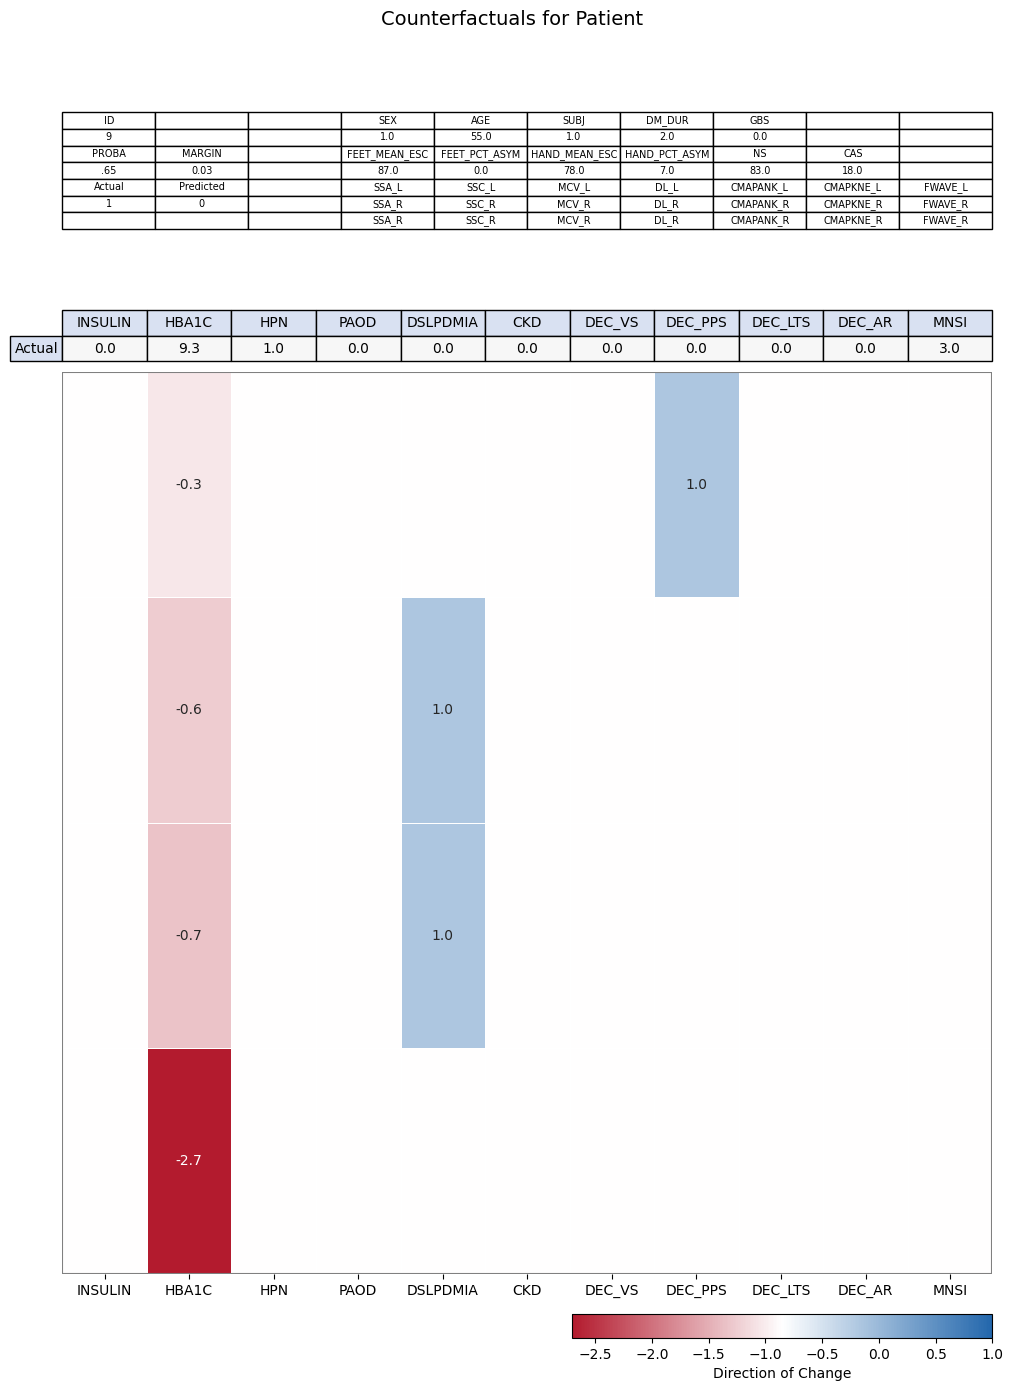

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. Load data and calculate changes
df = pd.read_csv(r'/home/toni_briza/dpn2026/module/experiments/binary/counterfactuals/catboost/final__nosudo__model_wt_auc__opt_auprc_f1/split0/nofiltering/059/catboost_split0_local_cf.csv')
df = df.drop(df.index[5:])

features = ['INSULIN', 'HBA1C', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI']
instance = df.iloc[0:1][features]
print(instance.columns)
cfs = df.iloc[1:][features]
changes = (cfs.values - instance.values).astype(float)

# 2. Define Custom Color Scheme (Red -> White -> Blue)
colors = ["#B31B2E", "#FFFFFF", "#2367AC"] 
custom_cmap = LinearSegmentedColormap.from_list("custom_diverging", colors)
annot_mask = np.where(np.isclose(changes, 0), "", np.round(changes, 1).astype(str))

##****************************************
nrows = df.shape[1]
cf_ht_ratio = max(6, np.ceil(5*nrows/10))
fig_height = max(6, 3 + np.ceil(5*(nrows/10))) 

##****************************************
# 3. Create Figure
print("*"*10, nrows,fig_height,cf_ht_ratio)
fig, (ax_meta_table, ax_table, ax_heatmap) = plt.subplots(3, 1, figsize=(12, 16), 
                                           gridspec_kw={'height_ratios': [4, 1, 14], 'hspace': 0.01})

# META VALUES ===========
# Set background for the heatmap axis
ax_meta_table.set_facecolor('#F7F7F7')
# print(df.iloc[0:1])
# print([df.iloc[0][f] for f in ["SEX","AGE","SUBJ","DM_DUR","GBS"]])
tb = lambda x: df.iloc[0][x]
table_vals = [
    ['ID',"","","SEX","AGE","SUBJ","DM_DUR","GBS", "", ""],
    ['9',"","", tb("SEX"), tb("AGE"), tb("SUBJ"), tb("DM_DUR"),tb("GBS"),"", ""],
    ['PROBA', 'MARGIN', '', 'FEET_MEAN_ESC','FEET_PCT_ASYM','HAND_MEAN_ESC','HAND_PCT_ASYM','NS','CAS', ""],
    [".65","0.03", "",  tb('FEET_MEAN_ESC'), tb('FEET_PCT_ASYM'),tb('HAND_MEAN_ESC'),tb('HAND_PCT_ASYM'),tb('NS'),tb('CAS'), ""],        
    ['Actual', 'Predicted', '', 'SSA_L', 'SSC_L', 'MCV_L', 'DL_L','CMAPANK_L','CMAPKNE_L','FWAVE_L'],
    ['1', '0', '', 'SSA_R', 'SSC_R', 'MCV_R', 'DL_R','CMAPANK_R','CMAPKNE_R','FWAVE_R'],
    ['', '', '', 'SSA_R', 'SSC_R', 'MCV_R', 'DL_R','CMAPANK_R','CMAPKNE_R','FWAVE_R'],
]

# --- Reference Table ---
meta_tbl = ax_meta_table.table(cellText=table_vals, loc='center', cellLoc='center')

# header_color = '#D9E1F2' 

# for (row, col), cell in tbl.get_celld().items():
#     if row == 0: # Header
#         cell.set_facecolor(header_color)
#         # cell.set_text_props(weight='bold')
#     elif col == -1: # Row labels
#         cell.set_facecolor('#D9E1F2')
#         # cell.set_text_props(weight='bold')
#     else:
#         cell.set_facecolor('#F7F7F7')
#     cell.set_height(0.4)

meta_tbl.auto_set_font_size(False)
meta_tbl.set_fontsize(7)
ax_meta_table.axis('off')

# INSTANCE VALUES ===========
# Set background for the heatmap axis
ax_heatmap.set_facecolor('#F7F7F7')

# --- Reference Table ---
table_vals = instance.values.round(2).astype(str)
tbl = ax_table.table(cellText=table_vals, colLabels=features, rowLabels=['Actual'], loc='center', cellLoc='center')

header_color = '#D9E1F2' 

for (row, col), cell in tbl.get_celld().items():
    if row == 0: # Header
        cell.set_facecolor(header_color)
        # cell.set_text_props(weight='bold')
    elif col == -1: # Row labels
        cell.set_facecolor('#D9E1F2')
        # cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('#F7F7F7')
    cell.set_height(0.4)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
ax_table.axis('off')

# --- Heatmap ---
sns.heatmap(changes, annot=annot_mask, fmt="", cmap=custom_cmap, center=0,
            xticklabels=features, 
            yticklabels=False, 
            ax=ax_heatmap, 
            cbar=False, # Disable default cbar to manually place it
            linewidths=0.5, linecolor='white')

# Custom gray gridlines
num_rows = changes.shape[0]
ax_heatmap.axhline(0, color='gray', linewidth=1.5)
for i in range(5, num_rows, 5):
    ax_heatmap.axhline(i, color='gray', linewidth=1.0)
ax_heatmap.axhline(num_rows, color='gray', linewidth=1.5)

# Vertical gray lines on both ends
ax_heatmap.axvline(0, color='gray', linewidth=1.5)
ax_heatmap.axvline(len(features), color='gray', linewidth=1.5)

# Identify non-feature metadata columns
instance_full = df.iloc[0]
all_cols = df.columns.tolist()
excluded_cols = features + ['Unnamed: 0']
other_cols = [c for c in all_cols if c not in excluded_cols]
other_values = instance_full[other_cols].to_dict()

# Format metadata string
meta_items = [f"{k}: {v}" for k, v in other_values.items()]
other_info_str = "Instance Meta-Data:\n" + ", ".join(meta_items[:7]) + "\n" + ", ".join(meta_items[7:])


# 4. Custom Horizontal Colorbar flushed to the rightmost
# pos = ax_heatmap.get_position()
# # Position: [left, bottom, width, height] relative to figure
# cbar_ax = fig.add_axes([pos.x1 - 0.35, pos.y0 - 0.05, 0.35, 0.015]) 
# norm = plt.Normalize(vmin=changes.min(), vmax=changes.max())
# sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label('Direction of Change', fontsize=10)

# --- Colorbar and Text ---
pos = ax_heatmap.get_position()
cbar_ax = fig.add_axes([pos.x1 - 0.35, pos.y0 - 0.04, 0.35, 0.015])
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=changes.min(), vmax=changes.max()))
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal').set_label('Direction of Change')

fig.suptitle('Counterfactuals for Patient', fontsize=14, y=0.9)
ax_heatmap.tick_params(left=False) 


plt.tight_layout()
plt.show()

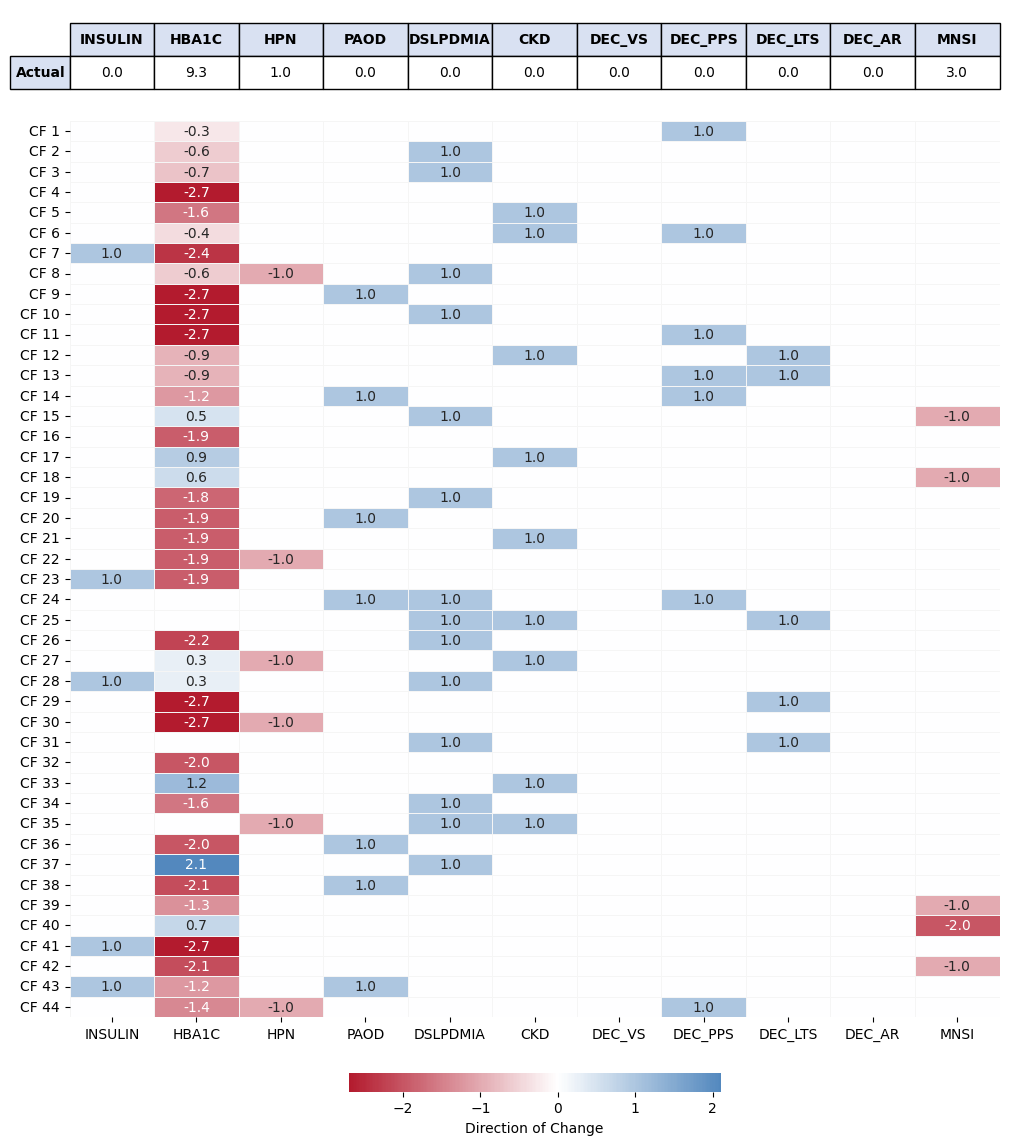

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. Load data and calculate changes
df = pd.read_csv(r'/home/toni_briza/dpn2026/module/experiments/binary/counterfactuals/catboost/final__nosudo__model_wt_auc__opt_auprc_f1/split0/nofiltering/059/catboost_split0_local_cf.csv')
features = ['INSULIN', 'HBA1C', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI']
instance = df.iloc[0:1][features]
cfs = df.iloc[1:][features]
changes = (cfs.values - instance.values).astype(float)

# 2. Define Custom Color Scheme from image (Red -> White -> Blue)
colors = ["#B31B2E", "#FFFFFF", "#2367AC"] 
custom_cmap = LinearSegmentedColormap.from_list("custom_diverging", colors)

# 3. Create annotation mask to hide 0.0 values
annot_mask = np.where(np.isclose(changes, 0), "", np.round(changes, 1).astype(str))

# 4. Setup Figure
fig = plt.figure(figsize=(12, 16))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 12], hspace=0.03)
ax_table = fig.add_subplot(gs[0])
ax_heatmap = fig.add_subplot(gs[1])

# --- Table (Actual Values) ---
table_vals = instance.values.round(2).astype(str)
tbl = ax_table.table(cellText=table_vals, colLabels=features, rowLabels=['Actual'], loc='center', cellLoc='center')

header_color = '#D9E1F2' 
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(weight='bold')
    if col == -1:
        cell.set_facecolor('#D9E1F2')
        cell.set_text_props(weight='bold')
    cell.set_height(0.35)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
ax_table.axis('off')

# --- Heatmap (Counterfactual Changes) ---
sns.heatmap(changes, annot=annot_mask, fmt="", cmap=custom_cmap, center=0,
            xticklabels=features, 
            yticklabels=[f'CF {i+1}' for i in range(len(cfs))],
            ax=ax_heatmap, 
            cbar_kws={'label': 'Direction of Change', 'orientation': 'horizontal', 'pad': 0.05, 'shrink': 0.4},
            linewidths=.5, linecolor='whitesmoke')

# ax_heatmap.set_title('Counterfactual Changes (Zeros Hidden)', pad=25, fontsize=16, weight='bold')
plt.tight_layout()
plt.show()